# 5. Future projections

In this chapter, the results of the future projections for the different climate scenarios and their yearly volumes are analyzed. First, the return times of the different hydrological drought categories are calculated using the historical percentiles of the observed data given in chapter 2.3. These return times are then compared to the historical return times. After the return times, the number of hydrological droughts are calculated for each drought category and compared to the historical number of droughts. Lastly, the change in rainfall of the catchment are analyzed for the different climate scenarios.  

## 5.1 Return times
Using the results of chapter 4.3, the return times of the yearly volumes are calculated. The results are shown in figure 5.1. In table 5.1, the return times of the historical percentile values, used to categorize dry years, are given in years. The code for calculating the return and plotting the figure is given below.

In [1]:
#Loading packages
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
#Function for return period
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

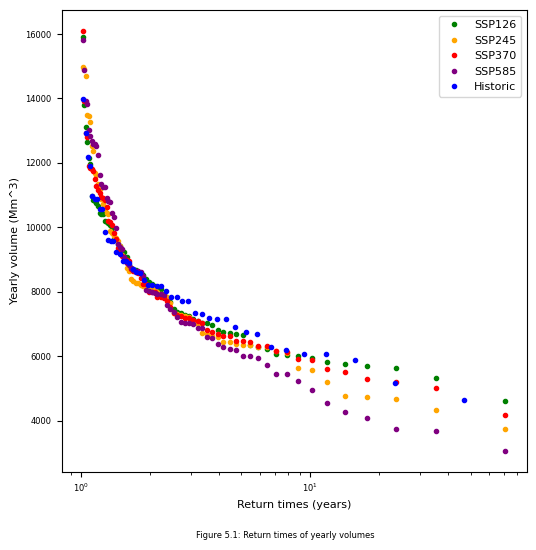

In [4]:
#Loading observed discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m$^3$/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

#Converting daily discharge in m^3/s to yearly volumes in Mm^3
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm$^3$)']

#Path to SSP scenario results
path_SSP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data"

#Loading yearly volume data for the different scenarios
SSP126_yearly = pd.read_csv(path_SSP / 'SSP126_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_yearly = pd.read_csv(path_SSP / 'SSP245_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_yearly = pd.read_csv(path_SSP / 'SSP370_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_yearly = pd.read_csv(path_SSP / 'SSP585_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

#Calculating return times
return_period_historic = return_periods(yearly_volume)
return_period_CMIP = return_periods(SSP126_yearly)

#Sorting data from low to high
historic_sorted = np.sort(yearly_volume['Yearly volume (Mm$^3$)'])
SSP126_yearly_sorted = np.sort(SSP126_yearly['SSP126'])
SSP245_yearly_sorted = np.sort(SSP245_yearly['SSP245'])
SSP370_yearly_sorted = np.sort(SSP370_yearly['SSP370'])
SSP585_yearly_sorted = np.sort(SSP585_yearly['SSP585'])

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(return_period_CMIP, SSP126_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP126', color='green')
plt.plot(return_period_CMIP, SSP245_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP245', color='orange')
plt.plot(return_period_CMIP, SSP370_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP370', color='red')
plt.plot(return_period_CMIP, SSP585_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP585', color='purple')
plt.plot(return_period_historic, historic_sorted, marker='o', linestyle='None', ms=3, label='Historic', color='blue')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=8)
plt.xscale('log')
plt.legend(fontsize=8)
fig.text(0.5, 0,"Figure 5.1: Return times of yearly volumes ", ha="center", fontsize=6);

In [10]:
#Retrieving percentile for different categories
percentile15 = np.percentile(yearly_volume, 15)
percentile10 = np.percentile(yearly_volume, 10)
percentile5 = np.percentile(yearly_volume, 5)

#Calculating return times of different categories for historic data
interpolate_func_h = interp1d(historic_sorted, return_period_historic, bounds_error=False, fill_value="extrapolate")
return15_h = interpolate_func_h(percentile15)
return10_h = interpolate_func_h(percentile10)
return5_h = interpolate_func_h(percentile5)

#Calculating return times of different categories for climate scenarios
CMIP_scenarios_yearly = [SSP126_yearly_sorted, SSP245_yearly_sorted, SSP370_yearly_sorted, SSP585_yearly_sorted]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
for i in range(len(CMIP_scenarios_yearly)):
    interpolate_func = interp1d(CMIP_scenarios_yearly[i], return_period_CMIP, bounds_error=False, fill_value="extrapolate")
    return15 = interpolate_func(percentile15)
    return10 = interpolate_func(percentile10)
    return5 = interpolate_func(percentile5)

|                         |**Historic**     |**SSP1-2.6**      |**SSP2-4.5**       |**SSP3-7.0**      |**SSP5-8.5**      |
|-------------------------|-----------------|------------------|-------------------|------------------|------------------|
| **Q15 (6591 Mm$^3$)**   |6.08             |5.16              |3.95               |4.49              |3.55              |
| **Q10 (6135 Mm$^3$)**   |8.62             |6.87              |7.42               |7.58              |4.85              |
| **Q5 (5937 Mm$^3$)**    |14.69            |10.39             |8.22               |8.83              |5.87              |

<div align="center">
<i>Table 5.1: Return times in years</i>
</div>

## 5.2 Future hydrological droughts
For determining the number of hydrological droughts, periods of 35 years are used. The first period is from 2030 to 2064 and the second period is from 2065 to 2099. The results are then compared to the number of droughts in the last 35 years of the observed data, from 1986 to 2020. In table 5.2, the number of years in the different hydrological drought categories are shown. The first number under the climate scenarios represent the first 35 year period and the second number represents the second 35 years. The code below shows how the number of dry years in the Okavango Delta is calculated.

In [14]:
#Number of years in each drought category for last 35 years of observation
historic35 = yearly_volume[-35::]
u15_historic35 = len(historic35[(historic35['Yearly volume (Mm$^3$)'] < percentile15) & (historic35['Yearly volume (Mm$^3$)'] > percentile10)])
u10_historic35 = len(historic35[(historic35['Yearly volume (Mm$^3$)'] < percentile10) & (historic35['Yearly volume (Mm$^3$)'] > percentile5)])
u5_historic35 = len(historic35[(historic35['Yearly volume (Mm$^3$)'] < percentile5)])

#Number of years in each drought category for climate scenarios
CMIP_scenarios = [SSP126_yearly, SSP245_yearly, SSP370_yearly, SSP585_yearly]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
for k in range(len(CMIP_scenarios)):
    SSP_data = CMIP_scenarios[k] 
    first35 = SSP_data[0:35]
    last35 = SSP_data[-35::]
    
    u15_first35 = len(first35[(first35[names[k]] < percentile15) & (first35[names[k]] > percentile10)])
    u15_last35 = len(last35[(last35[names[k]] < percentile15) & (last35[names[k]] > percentile10)])

    u10_first35 = len(first35[(first35[names[k]] < percentile10) & (first35[names[k]] > percentile5)])
    u10_last35 = len(last35[(last35[names[k]] < percentile10) & (last35[names[k]] > percentile5)])

    u5_first35 = len(first35[(first35[names[k]] < percentile5)])
    u5_last35 = len(last35[(last35[names[k]] < percentile5)])

|                |**Historic**     |**SSP1-2.6**      |**SSP2-4.5**       |**SSP3-7.0**      |**SSP5-8.5**      |
|----------------|-----------------|------------------|-------------------|------------------|------------------|
| **Moderate**   |1                |2 / 1             |2 / 6              |3 / 3             |4 / 2             |
| **Severe**     |2                |3 / 1             |0 / 1              |0 / 1             |0 / 2             |
| **Extreme**    |3                |3 / 3             |2 / 6              |1 / 7             |5 / 7             |

<div align="center">
<i>Table 5.2: Number of dry years per category</i>
</div>

## 5.3 Rainfall
As mentioned in the introduction, 95% of the water flowing in the Okavango River comes from the rainfall in the Angolan catchment area. The majority of the catchment area is located in Angola with 135,000 km2 compared to about 175,000 km2 for the whole catchment area. In figure 5.2, the return times of the yearly precipitation are shown for the different climate scenarios. As the HBV model output was showing bias when using historic CMIP forcing data, the precipitation is also bias corrected using quantile mapping. The quantile distribution of the ERA5 precipitation data are aligned with the historic CMIP precipitation data from. Here, it is assumed that the ERA5 precipitation data is correct. This same bias corrections is used on the future precipitation of the CMIP dataset. The code below shows how quantile mapping is used on the precipitation data and how the return times are calculated.

In [18]:
#Loading packages
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

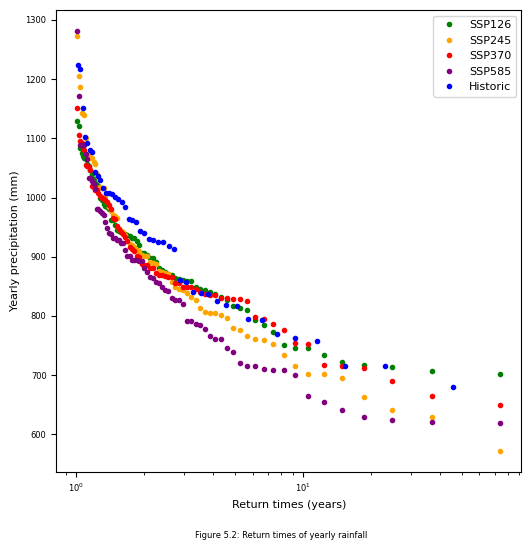

In [29]:
#Loading ERA5 data (same as used in chapter 3)
forcing_path_ERA5 = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/ERA5_HBV/own_shapefile_3"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

#Loading CMIP data (same as used in chapter 4)
forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP"  
historical_CMIP_location = forcing_path_CMIP / "historical" / "work" / "diagnostic" / "script"
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location)

#Loading CMIP data for the different climate scenarios
forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP_future"
scenarios = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
names = ['SSP126_CMIP_forcing', 'SSP245_CMIP_forcing', 'SSP370_CMIP_forcing', 'SSP585_CMIP_forcing']

for scenario, name in zip(scenarios, names):
    location = forcing_path_CMIP / scenario / "work" / "diagnostic" / "script"
    globals()[name] = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
        directory=location
    )

#Code of quantile mapping from Zoë Lucius (2025)
def quantile_mapping(observed, modelled, n):
    #Making a quantile grid 
    quantiles = np.linspace(0, 1, n)

    #Sorting data 
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    #Assigning every data point to a quantile
    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    #Aligning data points with quantile grid
    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    #Creating function to use on CMIP forcing data
    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

#Retrieving precipitation data
CMIP_historic_pr = xr.open_dataset(historical_CMIP_forcing['pr'])
CMIP_historic_pr = CMIP_historic_pr['pr'].to_series()

ERA5_pr = xr.open_dataset(ERA5_forcing['pr'])
ERA5_pr = ERA5_pr['pr'].to_series()
ERA5_pr = ERA5_pr["1970-01-01":"2014-12-31"]

forcing_data = [SSP126_CMIP_forcing, SSP245_CMIP_forcing, SSP370_CMIP_forcing, SSP585_CMIP_forcing]
names = ['CMIP_pr_SSP126', 'CMIP_pr_SSP245', 'CMIP_pr_SSP370', 'CMIP_pr_SSP585']

for forcing, name in zip(forcing_data, names):
    globals()[name] = xr.open_dataset(forcing['pr'])
    globals()[name] = globals()[name]['pr'].to_series()

#Using quantile with ERA5 and historic CMIP precipitation
qm_pr = quantile_mapping(ERA5_pr, CMIP_historic_pr, 1000)

#Using quantile mapping function on future CMIP precipitation
#Converting data from kg m^-2 s^-1 to mm/day and converting to yearly total
pr_corrected_SSP126 = qm_pr(CMIP_pr_SSP126)
df_SSP126_corrected = pd.DataFrame({'SSP126':pr_corrected_SSP126 * 86400}, index=CMIP_pr_SSP126.index)
SSP126_yearly_pr = df_SSP126_corrected.resample('YE').sum()
SSP126_yearly_pr.index = SSP126_yearly_pr.index.year

pr_corrected_SSP245 = qm_pr(CMIP_pr_SSP245)
df_SSP245_corrected = pd.DataFrame({'SSP245':pr_corrected_SSP245 * 86400}, index=CMIP_pr_SSP245.index)
SSP245_yearly_pr = df_SSP245_corrected.resample('YE').sum()
SSP245_yearly_pr.index = SSP245_yearly_pr.index.year

pr_corrected_SSP370 = qm_pr(CMIP_pr_SSP370)
df_SSP370_corrected = pd.DataFrame({'SSP370':pr_corrected_SSP370 * 86400}, index=CMIP_pr_SSP370.index)
SSP370_yearly_pr = df_SSP370_corrected.resample('YE').sum()
SSP370_yearly_pr.index = SSP370_yearly_pr.index.year

pr_corrected_SSP585 = qm_pr(CMIP_pr_SSP585)
df_SSP585_corrected = pd.DataFrame({'SSP585':pr_corrected_SSP585 * 86400}, index=CMIP_pr_SSP585.index)
SSP585_yearly_pr = df_SSP585_corrected.resample('YE').sum()
SSP585_yearly_pr.index = SSP585_yearly_pr.index.year

ERA5_pr = ERA5_pr * 86400
ERA5_yearly_pr = ERA5_pr.resample('YE').sum()
ERA5_yearly_pr.index = ERA5_yearly_pr.index.year

#Calculating return period
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

#Calculating return periods
historic_return_period = return_periods(ERA5_yearly_pr)
future_return_period = return_periods(SSP126_yearly_pr)

#Sorting data
SSP126_yearly_pr_sorted = np.sort(SSP126_yearly_pr['SSP126'])
SSP245_yearly_pr_sorted = np.sort(SSP245_yearly_pr['SSP245'])
SSP370_yearly_pr_sorted = np.sort(SSP370_yearly_pr['SSP370'])
SSP585_yearly_pr_sorted = np.sort(SSP585_yearly_pr['SSP585'])
ERA5_yearly_pr_sorted = np.sort(ERA5_yearly_pr)

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(future_return_period, SSP126_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='SSP126', color='green')
plt.plot(future_return_period, SSP245_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='SSP245', color='orange')
plt.plot(future_return_period, SSP370_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='SSP370', color='red')
plt.plot(future_return_period, SSP585_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='SSP585', color='purple')
plt.plot(historic_return_period, ERA5_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='Historic', color='blue')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly precipitation (mm)", fontsize=8)
plt.xscale('log')
plt.legend(fontsize=8)
fig.text(0.5, 0,"Figure 5.2: Return times of yearly rainfall", ha="center", fontsize=6);

## 5.4 Conclusion